# Branch Excel report: the numbers

Every number in the README comes from this notebook. It runs the pipeline, then measures and checks the result. Run it top to bottom (Run All). Client values (name, currency, colours, the quantity rule) come from `config/client.yaml`.

**How each number is measured**

- **Branch files:** the Excel files in `data/input/` that `run.py` reads.
- **Rows read:** the order lines under each file's header row. Title rows and totals rows are layout, not orders, so they are skipped and counted apart.
- **Errors caught:** the rows set aside, each with its reason: the rows that break a rule, plus lines pasted twice.
- **Rebuild time:** wall-clock seconds for `python run.py` on the computer that ran this notebook, from start to the finished Excel report.
- **Report numbers:** sums over `output/clean_sales.csv`. The Power BI report must show the same numbers (`powerbi/06-checks.md`).

In [1]:
import sqlite3
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import load_config

cfg = load_config()
NAME, CURRENCY = cfg["client"]["name"], cfg["client"]["currency"]
MAIN, MUTED = cfg["report"]["colours"]["data"][0], cfg["report"]["colours"]["muted"]
# Charts use the README's navy and teal look; the Power BI theme keeps client.yaml's colours.
MAIN, MUTED, TEXT, LINE = "#2DD4BF", "#94A3B8", "#E2E8F0", "#334155"
plt.rcParams.update({"figure.facecolor": "#0F172A", "axes.facecolor": "#0F172A", "savefig.facecolor": "#0F172A",
                     "text.color": TEXT, "axes.labelcolor": TEXT, "xtick.color": TEXT, "ytick.color": TEXT, "axes.edgecolor": LINE})
OUT, DOCS, INPUT = ROOT / "output", ROOT / "docs", cfg["input_dir"]

started = time.perf_counter()
run = subprocess.run([sys.executable, "run.py"], cwd=ROOT, check=True, capture_output=True, text=True)
seconds = time.perf_counter() - started
print(run.stdout)

192 files, 10089 rows read: 9836 clean, 253 set aside
reason
duplicate of an earlier row      96
amount not a number              37
date not readable                31
date outside the file's month    30
quantity missing or below 1      30
missing order id                 29
Report rebuilt in 13.0 seconds: output/weekly_report.xlsx



In [2]:
sales = pd.read_csv(OUT / "clean_sales.csv", parse_dates=["order_date"])
aside = pd.read_csv(OUT / "set_aside_rows.csv")
files = pd.read_csv(OUT / "file_log.csv")

DUPLICATE = "duplicate of an earlier row"
rows_read = files["rows_read"].sum()
headline = pd.Series({
    "Branch files": len(files),
    "Branches": files["branch"].nunique(),
    "Months": files["month"].nunique(),
    "Rows read": rows_read,
    "Clean rows": len(sales),
    "Errors caught (rows set aside)": len(aside),
    "  rows that break a rule": (aside["reason"] != DUPLICATE).sum(),
    "  lines pasted twice": (aside["reason"] == DUPLICATE).sum(),
    "Error rate %": round(100 * len(aside) / rows_read, 1),
    "Totals rows skipped (layout)": files["totals_rows_skipped"].sum(),
    "Rebuild seconds": round(seconds),
}, dtype=object)
headline.to_frame(NAME)

,Sample retail chain
Branch files,192
Branches,4
Months,48
Rows read,10089
Clean rows,9836
Errors caught (rows set aside),253
rows that break a rule,157
lines pasted twice,96
Error rate %,2.5
Totals rows skipped (layout),48


In [3]:
by_branch = pd.crosstab(aside["reason"], aside["branch"])
by_branch["Total"] = by_branch.sum(axis=1)
by_branch.sort_values("Total", ascending=False)

branch,Central,East,South,West,Total
reason,,,,,
duplicate of an earlier row,24,32,8,32,96
amount not a number,6,6,9,16,37
date not readable,6,7,8,10,31
date outside the file's month,8,9,7,6,30
quantity missing or below 1,7,8,4,11,30
missing order id,4,12,4,9,29


## Checks 1 and 2: the demo's answer key (demo files only)

These two checks run only when `data/input/` holds the demo files with their answer key, `planted_errors.csv`. A client's own files have no answer key, so the checks are skipped.

1. **Every planted mistake is caught, and nothing else:** the rows set aside must be exactly the planted rows, at the same file and row, for the same reason.
2. **Every clean row is a source line, with only its format fixed:** each clean row must match exactly one line of the source orders in `data/demo/`. The source hides non-breaking spaces inside some product names (they look like spaces but break a VLOOKUP); the cleaner turns them into normal spaces, so the source is compared with its spaces evened out.

In [4]:
answer_key = INPUT / "planted_errors.csv"
if answer_key.exists():
    planted = pd.read_csv(answer_key)
    match = aside.merge(planted, on=["file", "excel_row"], how="outer", indicator=True)
    assert (match["_merge"] == "both").all() and (match["reason"] == match["problem"]).all()
    print(f"Check 1: all {len(planted)} planted mistakes caught at the right file, row and reason; nothing else set aside.")

    cols = list(cfg["columns"])
    source = pd.read_csv(ROOT / "data" / "demo" / "source_orders.csv")
    source.columns = [c.lower().replace(" ", "_").replace("-", "_") for c in source.columns]
    source = source[cols].drop_duplicates()
    source["order_date"] = pd.to_datetime(source["order_date"])
    source[["sales", "profit"]] = source[["sales", "profit"]].round(2)
    hidden_space = source["product_name"].str.contains("\xa0")
    source["product_name"] = source["product_name"].str.replace(r"\s+", " ", regex=True).str.strip()
    check = sales.merge(source, on=cols, how="left", indicator=True)
    assert len(check) == len(sales) and (check["_merge"] == "both").all()
    print(f"Check 2: all {len(sales):,} clean rows match a source line exactly. {hidden_space.sum()} source lines "
          f"({source.loc[hidden_space, 'product_name'].nunique()} products) had hidden non-breaking spaces "
          "in the product name, fixed by the cleaner.")
else:
    print("No answer key in data/input/ (a client's own files): checks 1 and 2 skipped.")

Check 1: all 253 planted mistakes caught at the right file, row and reason; nothing else set aside.


Check 2: all 9,836 clean rows match a source line exactly. 225 source lines (47 products) had hidden non-breaking spaces in the product name, fixed by the cleaner.


## Check 3: SQL gives the same totals

The three output files are loaded into SQLite and counted again with plain SQL. These are the numbers the Power BI report must show (`powerbi/06-checks.md`).

In [5]:
db = sqlite3.connect(":memory:")
sales.assign(order_date=sales["order_date"].dt.strftime("%Y-%m-%d")).to_sql("clean_sales", db, index=False)
aside.to_sql("set_aside_rows", db, index=False)
files.to_sql("file_log", db, index=False)

sql_quality = pd.read_sql("""
    SELECT (SELECT COUNT(*) FROM file_log)            AS files,
           (SELECT SUM(rows_read) FROM file_log)      AS rows_read,
           (SELECT COUNT(*) FROM clean_sales)         AS clean_rows,
           (SELECT COUNT(*) FROM set_aside_rows)      AS set_aside_rows""", db)
sql_branch = pd.read_sql("""
    SELECT branch,
           COUNT(*)                 AS order_lines,
           COUNT(DISTINCT order_id) AS orders,
           ROUND(SUM(sales), 2)     AS sales,
           ROUND(SUM(profit), 2)    AS profit
    FROM clean_sales
    GROUP BY branch
    ORDER BY branch""", db)

assert sql_quality.iloc[0].tolist() == [len(files), rows_read, len(sales), len(aside)]
pandas_branch = sales.groupby("branch").agg(order_lines=("order_id", "size"), orders=("order_id", "nunique"),
                                            sales=("sales", "sum"), profit=("profit", "sum")).round(2)
assert (pandas_branch.reset_index().round(2) == sql_branch).all().all()
display(sql_quality)
sql_branch

,files,rows_read,clean_rows,set_aside_rows
0,192,10089,9836,253


,branch,order_lines,orders,sales,profit
0,Central,2292,1169,496613.97,39073.61
1,East,2805,1391,666739.35,90362.30
2,South,1588,811,387897.39,45874.58
3,West,3151,1600,714519.07,107342.94


## The report numbers

The totals the weekly report and the Power BI report show, in the client's currency. An order is one order ID; an order line is one product on an order.

In [6]:
total = pd.Series({
    f"Sales ({CURRENCY})": round(sales["sales"].sum(), 2),
    f"Profit ({CURRENCY})": round(sales["profit"].sum(), 2),
    "Profit margin %": round(100 * sales["profit"].sum() / sales["sales"].sum(), 1),
    "Orders": sales["order_id"].nunique(),
    "Order lines": len(sales),
    "First order date": sales["order_date"].min().date(),
    "Last order date": sales["order_date"].max().date(),
}, dtype=object)
display(total.to_frame(NAME))
by_year = sales.groupby(sales["order_date"].dt.year).agg(sales=("sales", "sum"), profit=("profit", "sum"),
                                                          orders=("order_id", "nunique")).round(2)
by_category = sales.groupby("category").agg(sales=("sales", "sum"), profit=("profit", "sum")).round(2)
display(by_year)
by_category

,Sample retail chain
Sales (USD),2265769.78
Profit (USD),282653.43
Profit margin %,12.5
Orders,4971
Order lines,9836
First order date,2016-01-03
Last order date,2019-12-30


,sales,profit,orders
order_date,,,
2016,479525.73,49522.56,964
2017,458825.00,60373.85,1027
2018,601889.95,80337.91,1306
2019,725529.10,92419.11,1674


,sales,profit
category,,
Furniture,724968.37,17082.68
Office Supplies,709565.40,120586.72
Technology,831236.01,144984.03


## Charts for the README

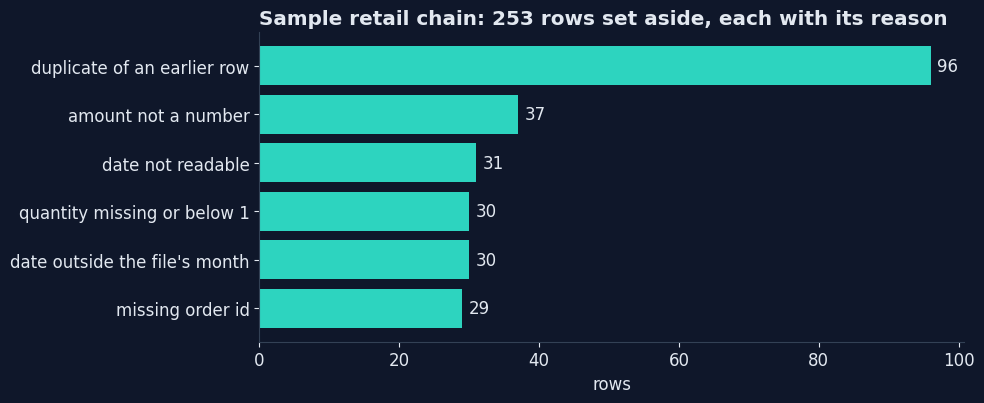

In [7]:
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False})

counts = aside["reason"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(counts.index, counts.values, color=MAIN)
for y, v in enumerate(counts.values):
    ax.text(v + counts.max() / 100, y, str(v), va="center")
ax.set_title(f"{NAME}: {len(aside)} rows set aside, each with its reason", loc="left", fontweight="bold")
ax.set_xlabel("rows")
fig.tight_layout()
fig.savefig(DOCS / "errors-by-reason.png", dpi=150)
plt.show()

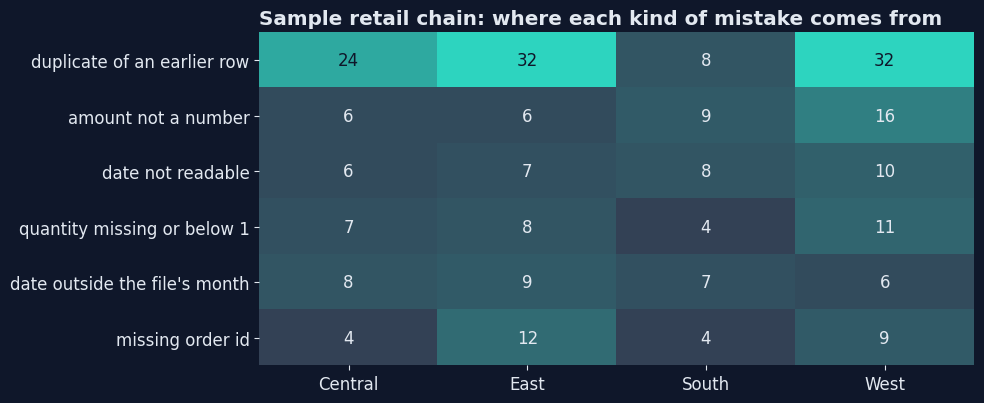

In [8]:
grid = pd.crosstab(aside["reason"], aside["branch"]).loc[counts.index[::-1]]
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(grid.values, cmap=LinearSegmentedColormap.from_list("line_to_main", [LINE, MAIN]), aspect="auto")
ax.set_xticks(range(len(grid.columns)), grid.columns)
ax.set_yticks(range(len(grid.index)), grid.index)
for (y, x), v in pd.DataFrame(grid.values).stack().items():
    ax.text(x, y, str(v), ha="center", va="center", color="#0F172A" if v > grid.values.max() / 2 else TEXT)
ax.set_title(f"{NAME}: where each kind of mistake comes from", loc="left", fontweight="bold")
ax.spines[:].set_visible(False)
fig.tight_layout()
fig.savefig(DOCS / "errors-by-branch.png", dpi=150)
plt.show()

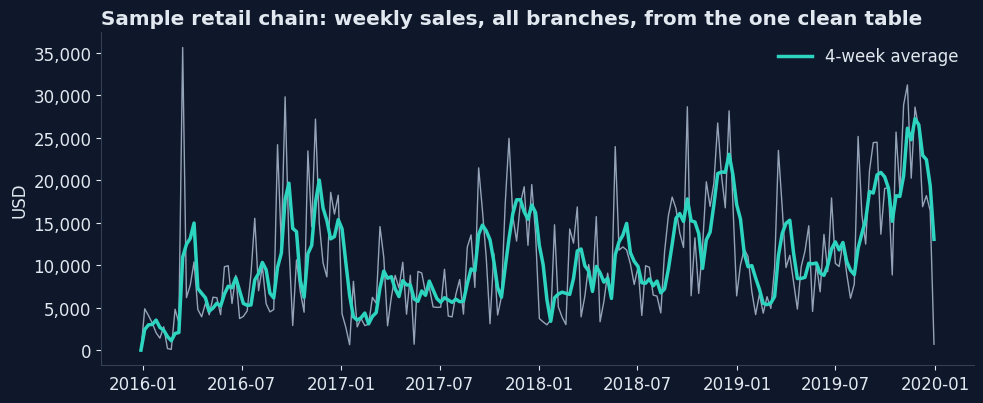

In [9]:
weekly = sales.groupby(sales["order_date"].dt.to_period("W-SUN").dt.start_time)["sales"].sum()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(weekly.index, weekly.values, color=MUTED, linewidth=1)
ax.plot(weekly.index, weekly.rolling(4, min_periods=1).mean().values, color=MAIN, linewidth=2.5, label="4-week average")
ax.set_title(f"{NAME}: weekly sales, all branches, from the one clean table", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.set_ylabel(CURRENCY)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(DOCS / "weekly-sales.png", dpi=150)
plt.show()

## The result in one line

In [10]:
print(f"{len(files)} branch Excel files merged into one weekly report in one click")
print(f"{rows_read:,} rows across {len(files)} branch files: {len(aside)} errors caught, "
      f"report rebuilt in {round(seconds)} seconds")

192 branch Excel files merged into one weekly report in one click
10,089 rows across 192 branch files: 253 errors caught, report rebuilt in 14 seconds
